# Task 3 — DLRM from scratch



In [1]:
!pip -q install scikit-learn pandas matplotlib
import torch; print(torch.__version__, 'GPU' if torch.cuda.is_available() else 'CPU')

2.11.0+cu128 GPU


### Data


In [2]:
import os
from google.colab import files
DATA_DIR = "/content/datasets"
os.makedirs(DATA_DIR, exist_ok=True)
up = files.upload()                       # select the zip
for name, content in up.items():
    open(os.path.join(DATA_DIR, name), "wb").write(content)


Saving dataset (tasks 2 and 3) (1).zip to dataset (tasks 2 and 3) (1).zip


### Loading, preprocessing, training loop, metrics


In [3]:
import copy, glob, os, random, time, zipfile
import numpy as np
import pandas as pd
import torch
import math
import json
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss, accuracy_score,
                             f1_score, precision_score, recall_score, precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

### Loading


In [4]:
def _read(path, nrows=None):
    if path.endswith(".parquet"):
        df = pd.read_parquet(path)
        return df.head(nrows) if nrows else df
    df = pd.read_csv(path, nrows=nrows)
    if df.shape[1] == 1:                                   # tab separated
        df = pd.read_csv(path, sep="\t", nrows=nrows)
    return df


def load_data(data_dir, nrows=None):
    """Unzips (if needed), finds the train/test files, returns raw train_df, test_df, num_cols, cat_cols."""
    for z in glob.glob(os.path.join(data_dir, "*.zip")):
        out = os.path.join(data_dir, "_unzipped")
        if not os.path.exists(out):
            zipfile.ZipFile(z).extractall(out)
    files = [f for f in glob.glob(os.path.join(data_dir, "**", "*"), recursive=True)
             if f.lower().endswith((".csv", ".tsv", ".txt", ".parquet"))]
    tr_f = [f for f in files if "train" in os.path.basename(f).lower()]
    te_f = [f for f in files if "test" in os.path.basename(f).lower()]
    assert tr_f and te_f, f"could not find train/test files in {data_dir}: {files}"
    train, test = _read(tr_f[0], nrows), _read(te_f[0], nrows)
    feats = [c for c in train.columns if c != "label"]
    assert len(feats) == 39, f"expected 39 feature columns, got {len(feats)}: {feats}"
    NUM_COLS, CAT_COLS = feats[:13], feats[13:]
    return train, test, NUM_COLS, CAT_COLS

### Preprocessing (fit on train only → no leakage)
Numeric: median-impute, clip negatives, log1p, standardise.

Categorical: train vocabulary, rare/unseen values → id 0 (UNK).

In [5]:
class Preprocessor:
    """
    Everything is FIT ON TRAIN ONLY (no leakage):
      numeric     : missing -> train median ; clip negatives to 0 ; log1p (counts are heavy tailed) ; standardise
      categorical : value -> integer id from a train vocabulary.  id 0 = rare/unseen/'UNK'.
                    Values seen < min_count times in train are mapped to 0 too (keeps embedding tables small
                    and teaches the UNK row what 'rare' looks like).
    """
    def __init__(self, min_count=5, max_vocab=100_000):
        self.min_count, self.max_vocab = min_count, max_vocab

    def _num(self, df):
        x = df[self.num_cols].astype(float).fillna(self.median).clip(lower=0)
        return np.log1p(x)

    def fit(self, df, num_cols, cat_cols):
        self.num_cols, self.cat_cols = num_cols, cat_cols
        self.median = df[num_cols].astype(float).median()
        x = self._num(df)
        self.mean, self.std = x.mean(), x.std().replace(0, 1.0)
        self.vocab = {}
        for c in cat_cols:
            vc = df[c].astype(str).value_counts()
            vc = vc[vc >= self.min_count].head(self.max_vocab)
            self.vocab[c] = {v: i + 1 for i, v in enumerate(vc.index)}
        self.cards = [len(self.vocab[c]) + 1 for c in cat_cols]        # +1 for UNK
        return self

    def transform(self, df):
        dense = ((self._num(df) - self.mean) / self.std).values.astype(np.float32)
        sparse = np.stack([df[c].astype(str).map(self.vocab[c]).fillna(0).astype(np.int64).values
                           for c in self.cat_cols], axis=1)
        y = df["label"].values.astype(np.float32)
        return (torch.from_numpy(dense), torch.from_numpy(sparse), torch.from_numpy(y))


def prepare(data_dir, nrows=None, val_frac=0.1):
    """train file -> (train, val) stratified split ; test file untouched until the very end."""
    train_raw, test_raw, num_cols, cat_cols = load_data(data_dir, nrows)
    tr_df, va_df = train_test_split(train_raw, test_size=val_frac, random_state=SEED,
                                    stratify=train_raw["label"])
    pp = Preprocessor().fit(tr_df, num_cols, cat_cols)
    data = {"train": pp.transform(tr_df), "val": pp.transform(va_df), "test": pp.transform(test_raw),
            "cards": pp.cards, "n_dense": len(num_cols)}
    print(f"train={len(tr_df)} val={len(va_df)} test={len(test_raw)} | CTR train={tr_df.label.mean():.4f}"
          f" | total embedding rows={sum(pp.cards):,} | device={DEVICE}")
    return data, (tr_df, pp)

### Building blocks

In [6]:
def mlp(sizes, dropout=0.0, last_act=False):
    """sizes = [in, h1, ..., out].  ReLU between layers; optional ReLU after the last one."""
    layers = []
    for a, b in zip(sizes[:-1], sizes[1:]):
        layers += [nn.Linear(a, b), nn.ReLU()]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
    if not last_act:
        layers = layers[:-2] if dropout > 0 else layers[:-1]           # ReLU (+Dropout)
    return nn.Sequential(*layers)


def count_params(model):
    return sum(p.numel() for p in model.parameters())

### Training (Adam + BCE, early stopping on validation log-loss) and prediction

In [7]:
@torch.no_grad()
def predict(model, split, bs=8192):
    model.eval()
    dense, sparse, _ = split
    out = [torch.sigmoid(model(dense[i:i + bs].to(DEVICE), sparse[i:i + bs].to(DEVICE))).cpu()
           for i in range(0, len(dense), bs)]
    return torch.cat(out).numpy()


def fit(model, train, val, epochs=10, bs=2048, lr=1e-3, patience=2, verbose=True):
    """Adam + BCE-with-logits, early stopping on VALIDATION log-loss; restores the best weights."""
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.BCEWithLogitsLoss()
    dense, sparse, y = train
    n = len(y)
    hist = {"train_loss": [], "val_loss": [], "val_auc": []}
    best, best_state, bad = 1e9, None, 0
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n)
        tot = 0.0
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            d, s, t = dense[idx].to(DEVICE), sparse[idx].to(DEVICE), y[idx].to(DEVICE)
            opt.zero_grad()
            loss = lossf(model(d, s), t)
            loss.backward()
            opt.step()
            tot += loss.item() * len(idx)
        pv = predict(model, val)
        vl = log_loss(val[2].numpy(), np.clip(pv, 1e-7, 1 - 1e-7))
        va = roc_auc_score(val[2].numpy(), pv)
        hist["train_loss"].append(tot / n); hist["val_loss"].append(vl); hist["val_auc"].append(va)
        if verbose:
            print(f"   epoch {ep+1:2d}  train loss {tot/n:.4f}  val loss {vl:.4f}  val AUC {va:.4f}")
        if vl < best - 1e-5:
            best, best_state, bad = vl, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= patience:
                print("   early stop"); break
    model.load_state_dict(best_state)
    return hist, time.time() - t0

### Evaluation
The decision threshold is picked on validation (best F1) and then applied to test.

In [8]:
def best_f1_threshold(y, p):
    """Pick the decision threshold on VALIDATION data (CTR is imbalanced, 0.5 is rarely optimal)."""
    pr, rc, th = precision_recall_curve(y, p)
    f1 = 2 * pr[:-1] * rc[:-1] / np.maximum(pr[:-1] + rc[:-1], 1e-12)
    return float(th[int(np.argmax(f1))])


def metrics(y, p, threshold):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    yh = (p >= threshold).astype(int)
    return {"roc_auc": roc_auc_score(y, p), "pr_auc": average_precision_score(y, p),
            "logloss": log_loss(y, p), "accuracy": accuracy_score(y, yh),
            "f1": f1_score(y, yh), "precision": precision_score(y, yh, zero_division=0),
            "recall": recall_score(y, yh), "threshold": threshold}


def evaluate(model, data):
    """threshold chosen on val, then applied to test."""
    yv, yt = data["val"][2].numpy(), data["test"][2].numpy()
    pv, pt = predict(model, data["val"]), predict(model, data["test"])
    th = best_f1_threshold(yv, pv)
    return metrics(yv, pv, th), metrics(yt, pt, th), pt

### Plots

In [9]:
def plot_curves(histories, path):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        l, = ax[0].plot(h["val_loss"], label=f"{name} val")
        ax[0].plot(h["train_loss"], "--", color=l.get_color(), alpha=.6)
    ax[0].set(title="log-loss (solid = val, dashed = train)", xlabel="epoch"); ax[0].legend(fontsize=7)
    for name, h in histories.items():
        ax[1].plot(h["val_auc"], label=name)
    ax[1].set(title="validation ROC-AUC", xlabel="epoch"); ax[1].legend(fontsize=7)
    plt.tight_layout(); plt.savefig(path, dpi=130); plt.show()


def plot_calibration(y, preds, path):
    plt.figure(figsize=(5, 5))
    for name, p in preds.items():
        frac, mean = calibration_curve(y, p, n_bins=15, strategy="quantile")
        plt.plot(mean, frac, "o-", label=name, ms=3)
    lim = max(0.05, float(np.max([p.max() for p in preds.values()])))
    plt.plot([0, lim], [0, lim], "k--", label="perfect")
    plt.xlabel("mean predicted CTR"); plt.ylabel("observed CTR"); plt.title("Reliability (test)")
    plt.legend(fontsize=7); plt.tight_layout(); plt.savefig(path, dpi=130); plt.show()

## The DLRM model (Deep Learning Recommendation Model)


In [10]:
class DLRM(nn.Module):
    def __init__(self, cards, n_dense, emb_dim=16, bottom=(64,), top=(256, 128), interaction="dot", dropout=0.0):
        super().__init__()
        self.interaction = interaction
        # bottom MLP maps 13 dense features -> a vector of the SAME size as the embeddings (so they can be dotted)
        self.bottom = mlp([n_dense, *bottom, emb_dim], last_act=True)
        self.embs = nn.ModuleList([nn.Embedding(c, emb_dim) for c in cards])
        for e, c in zip(self.embs, cards):
            bound = math.sqrt(1.0 / c)
            nn.init.uniform_(e.weight, -bound, bound)
        n = len(cards) + 1                                       # number of vectors entering the interaction
        if interaction == "dot":
            top_in = emb_dim + n * (n - 1) // 2                  # z itself + every distinct pair (n choose 2)
            self.register_buffer("tril", torch.tril_indices(n, n, offset=-1))   # strictly-lower-triangle indices
        else:                                                    # 'cat' ablation: no explicit pairwise products, just concatenation of all vectors
            top_in = n * emb_dim
        self.top = mlp([top_in, *top, 1], dropout)

    def forward(self, dense, sparse):
        z = self.bottom(dense)                                               # (B, d)
        vecs = [z] + [emb(sparse[:, i]) for i, emb in enumerate(self.embs)]
        T = torch.stack(vecs, dim=1)                                         # (B, 27, d)
        if self.interaction == "dot":
            Z = torch.bmm(T, T.transpose(1, 2))                              # (B, 27, 27): Z[b,i,j] = <v_i, v_j>
            flat = Z[:, self.tril[0], self.tril[1]]                          # (B, 351): each pair once, no diagonal
            x = torch.cat([z, flat], dim=1)
        else:
            x = T.flatten(1)
        return self.top(x).squeeze(1)

## Config, data

In [11]:
NROWS = None          # e.g. 200_000 for a quick dry run
EPOCHS = 10
BS = 2048
OUT = "/content/outputs"; os.makedirs(OUT, exist_ok=True)

set_seed()
data, (tr_df, pp) = prepare(DATA_DIR, NROWS)
cards, nd = data["cards"], data["n_dense"]

train=36000 val=4000 test=10000 | CTR train=0.0320 | total embedding rows=10,970 | device=cuda


## Train the main DLRM and the ablations

In [12]:
configs = {
    "DLRM (dot, d=16)":          dict(emb_dim=16, interaction="dot"),
    "ablation: no interaction":  dict(emb_dim=16, interaction="cat"),   # plain concatenation, no explicit pairwise products
    "ablation: d=8":             dict(emb_dim=8,  interaction="dot"),
    "ablation: d=32":            dict(emb_dim=32, interaction="dot"),
    "ablation: tiny bottom MLP": dict(emb_dim=16, interaction="dot", bottom=()),
}
MAIN = "DLRM (dot, d=16)"
hists, val_res, test_res, info, preds = {}, {}, {}, {}, {}
for name, cfg in configs.items():
    print(f"\n== {name}")
    set_seed()
    m = DLRM(cards, nd, **cfg)
    hist, secs = fit(m, data["train"], data["val"], epochs=EPOCHS, bs=BS)
    v, t, pt = evaluate(m, data)
    hists[name], val_res[name], test_res[name], preds[name] = hist, v, t, pt
    info[name] = {"params": count_params(m), "train_seconds": round(secs, 1), "param_MB_fp32": round(count_params(m) * 4 / 1e6, 1)}
    print(f"   val logloss {v['logloss']:.4f}  AUC {v['roc_auc']:.4f} | params {info[name]['params']:,}")


== DLRM (dot, d=16)
   epoch  1  train loss 0.5213  val loss 0.1892  val AUC 0.4890
   epoch  2  train loss 0.1724  val loss 0.1486  val AUC 0.6016
   epoch  3  train loss 0.1397  val loss 0.1367  val AUC 0.6670
   epoch  4  train loss 0.1288  val loss 0.1346  val AUC 0.6949
   epoch  5  train loss 0.1191  val loss 0.1349  val AUC 0.7034
   epoch  6  train loss 0.1069  val loss 0.1405  val AUC 0.6887
   early stop
   val logloss 0.1346  AUC 0.6949 | params 304,689

== ablation: no interaction
   epoch  1  train loss 0.4431  val loss 0.1523  val AUC 0.5155
   epoch  2  train loss 0.1704  val loss 0.1409  val AUC 0.5948
   epoch  3  train loss 0.1396  val loss 0.1366  val AUC 0.6625
   epoch  4  train loss 0.1301  val loss 0.1338  val AUC 0.7047
   epoch  5  train loss 0.1203  val loss 0.1340  val AUC 0.7064
   epoch  6  train loss 0.1101  val loss 0.1410  val AUC 0.6799
   early stop
   val logloss 0.1338  AUC 0.7047 | params 321,329

== ablation: d=8
   epoch  1  train loss 0.5161  va

## Ablation results (validation set — the test set is not used for ablations)

,roc_auc,pr_auc,logloss,f1,params,train_seconds,param_MB_fp32
"DLRM (dot, d=16)",0.6949,0.0735,0.1346,0.1466,304689.0,3.5,1.2
ablation: no interaction,0.7047,0.0876,0.1338,0.1415,321329.0,1.1,1.3
ablation: d=8,0.6913,0.0790,0.1344,0.1493,214361.0,0.9,0.9
ablation: d=32,0.6943,0.0770,0.1342,0.1449,485345.0,1.0,1.9
ablation: tiny bottom MLP,0.7035,0.0787,0.1347,0.1623,302977.0,1.1,1.2


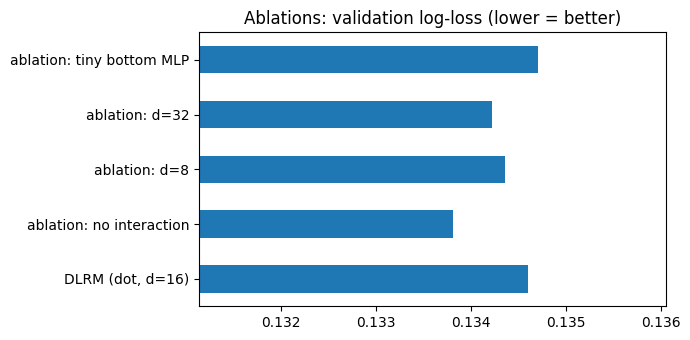

In [13]:
abl = pd.DataFrame(val_res).T[["roc_auc", "pr_auc", "logloss", "f1"]].join(pd.DataFrame(info).T)
display(abl.round(4))
abl.round(5).to_csv(f"{OUT}/ablations_val.csv")
ax = abl["logloss"].plot.barh(figsize=(7, 3.5), title="Ablations: validation log-loss (lower = better)")
ax.set_xlim(abl["logloss"].min() * 0.98, abl["logloss"].max() * 1.01)
plt.tight_layout(); plt.savefig(f"{OUT}/task3_ablations.png", dpi=130); plt.show()

## Final comparison on the test set (Task 2 models vs DLRM)

In [14]:
rows = {}
t2 = f"{OUT}/results_task2.json"
if os.path.exists(t2):
    r2 = json.load(open(t2))
    for n in (r2["selected_vanilla"], "DCN (emb16, 3 cross + [256,128])"):
        rows["Task2: " + n] = {**r2["test"][n], **r2["info"][n]}
else:
    print("results_task2.json not found in OUT -> table will only contain DLRM. Run Task 2 first / upload the file.")
rows["Task3: " + MAIN] = {**test_res[MAIN], **info[MAIN]}
final = pd.DataFrame(rows).T
display(final.round(4))
final.round(5).to_csv(f"{OUT}/final_comparison_test.csv")
json.dump({"val": val_res, "test": test_res, "info": info}, open(f"{OUT}/results_task3.json", "w"), indent=2, default=float)

results_task2.json not found in OUT -> table will only contain DLRM. Run Task 2 first / upload the file.


,roc_auc,pr_auc,logloss,accuracy,f1,precision,recall,threshold,params,train_seconds,param_MB_fp32
"Task3: DLRM (dot, d=16)",0.6883,0.0733,0.1406,0.9011,0.1162,0.0829,0.194,0.0616,304689.0,3.5,1.2


## Curves and calibration

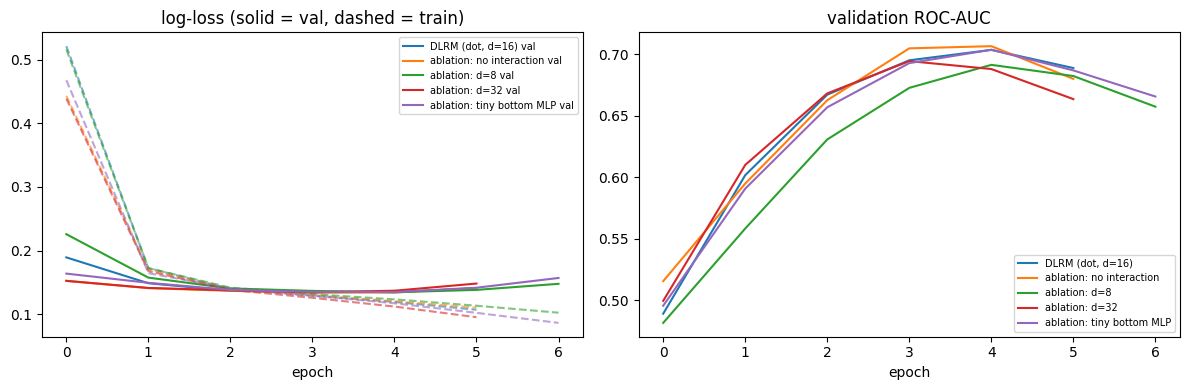

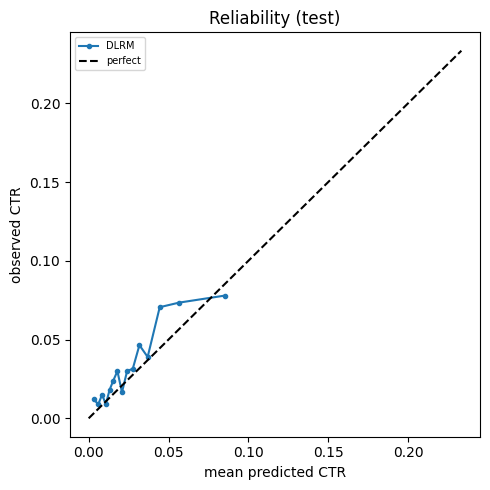

In [15]:
plot_curves(hists, f"{OUT}/task3_curves.png")
plot_calibration(data["test"][2].numpy(), {"DLRM": preds[MAIN]}, f"{OUT}/task3_calibration.png")

## Conclusion

* The ablation study shows that changing individual components of the DLRM architecture has only a small impact on overall validation performance. The different variants remain relatively close to the baseline, suggesting that the model is not highly sensitive to these architectural changes.

* The no-interaction variant achieved the best ROC-AUC (0.7047), PR-AUC (0.0876), and validation log-loss (0.1338). This shows that removing explicit feature interactions slightly improves the main validation metrics, indicating that the interaction component does not provide a clear benefit on this dataset.

* Changing the embedding dimension also had a limited effect. The d=8 variant achieved a ROC-AUC of 0.6913, while d=32 achieved 0.6943, compared with 0.6949 for the baseline. This suggests that increasing the embedding dimension does not necessarily improve performance and may add parameters without providing a meaningful gain.

* The tiny bottom MLP variant achieved the highest F1-score (0.1623), but its validation log-loss (0.1347) and ROC-AUC (0.7035) were not the best. This indicates that its improvement is mainly reflected in the F1 metric rather than representing a consistent improvement across all evaluation metrics.

* Overall, the results suggest that increasing model capacity or adding architectural components does not lead to a substantial improvement for this task. The differences between the variants are relatively small, and the baseline DLRM remains competitive. Therefore, the experiments indicate that a simpler architecture may provide comparable validation performance while using fewer computational resources.

* This might not be the case for every other dataset.